<a href="https://colab.research.google.com/github/Rennuaqsha/Code_BrainCancer/blob/BrainCancer/brain_cancer_Densenet_(99).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install tensorflow==2.8.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 498.0/498.0 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 111.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.3/462.3 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 108.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.3/781.3 kB 51.9 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.5.0
    Uninstalling keras-3.5.0:
      Successfully uninstalled keras-3.5.0
  Attempting uninstall: tensorboard-data-server
    Found existing installation: tensorboard-data-server 0.7.2
    Uninstalling tensorboard-data-server-0.7.2:
      Successfully uninstalled tensorboard-data-server-0.7.2
  Attempting uninstall: google-auth-oauthlib
    Found existing installation: g

In [ ]:
!pip install protobuf==3.20.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.5
    Uninstalling protobuf-4.25.5:
      Successfully uninstalled protobuf-4.25.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.62.3 requires protobuf>=4.21.6, but you have protobuf 3.20.3 which is incompatible.
pandas-gbq 0.26.1 requires google-auth-oauthlib>=0.7.0, but you have google-auth-oauthlib 0.4.6 which is incompatible.
tf-keras 2.17.0 requires tensorflow<2.18,>=2.17, but you have tensorflow 2.8.1 which is incompatible.


In [ ]:
!pip install kaggle==1.5.12

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.0/59.0 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for kaggle: filename=kaggle-1.5.12-py3-none-any.whl size=73026 sha256=ef103499a94cc464cc93e0fbbbbda3fc66ffeaf160f4a9dcb3bf756de0093d4c
  Stored in directory: /root/.cache/pip/wheels/70/0c/e6/79103212a102e78b8453691b905f48000219574ba7137e7207
Successfully built kaggle
  Attempting uninstall: kaggle
    Found existing installation: kaggle 1.6.17
    Uninstalling kaggle-1.6.17:
      Successfully uninstalled kaggle-1.6.17


In [ ]:
import kagglehub
Multi_Cancer_path = kagglehub.dataset_download('obulisainaren/multi-cancer')
print('Data source import complete.')

100%|██████████| 8.62G/8.62G [00:58<00:00, 158MB/s]

Extracting files...


Data source import complete.


In [ ]:
import os

# Cek lokasi dataset yang diunduh
print("Dataset Path:", Multi_Cancer_path)

Dataset Path: /root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3


In [ ]:
import os

# Path ke folder yang ingin dicek
folder_path = "/root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3/Multi Cancer/Multi Cancer/Brain Cancer"

# Cek apakah folder ada
if os.path.exists(folder_path):
    # List isi folder
    folder_contents = os.listdir(folder_path)
    print(f"Isi folder {folder_path}:")
    for item in folder_contents:
        print(f"- {item}")
else:
    print(f"Folder {folder_path} tidak ditemukan.")


Isi folder /root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3/Multi Cancer/Multi Cancer/Brain Cancer:
- brain_menin
- brain_glioma
- brain_tumor


In [ ]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
# import keras
from sklearn.datasets import load_files
from google.colab import files

from tensorflow import keras

from timeit import default_timer as timer
import time

# Display
from IPython.display import Image, display
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# from keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.utils import img_to_array

# import matplotlib.pyplot as plt

from tensorflow.keras.utils import to_categorical # Import to_categorical from tensorflow.keras.utils
from keras.models import Model
from keras import optimizers
from tensorflow.keras.optimizers import SGD, Adam, Optimizer
from tensorflow.keras import applications
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.densenet import DenseNet201




from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img
from keras.preprocessing import image

from keras.layers import GlobalAveragePooling2D,Dense,Flatten,Dropout
from keras.models import Sequential
from keras.callbacks import ModelCheckpoint
from sklearn.model_selection import KFold, train_test_split

from sklearn import svm, datasets
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

from keras.models import load_model

In [ ]:
# Load your dataset
data_dir = '/root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3/Multi Cancer/Multi Cancer/Brain Cancer'
data = load_files(data_dir)
X = np.array(data['filenames'])
y = np.array(data['target'])
labels = np.array(data['target_names'])

# Check the shape of the original dataset
print('Original number of files:', X.shape[0])
print('Original number of targets:', y.shape[0])

# Set the random seed for reproducibility
np.random.seed(2)

# Randomly select 1000 indices from the total number of files (5000)
random_indices = np.random.choice(X.shape[0], size=800, replace=False)

# Create new arrays for the randomly selected files and targets
X_random = X[random_indices]
y_random = y[random_indices]

# How the new arrays look like?
print('Randomly selected Data files - ', X_random)
print('Randomly selected Target labels - ', y_random)
print('Number of randomly selected files:', X_random.shape[0])
print('Number of randomly selected targets:', y_random.shape[0])

# Clean up
del data

Original number of files: 15000
Original number of targets: 15000
Randomly selected Data files -  ['/root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3/Multi Cancer/Multi Cancer/Brain Cancer/brain_menin/brain_menin_2702.jpg'
 '/root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3/Multi Cancer/Multi Cancer/Brain Cancer/brain_menin/brain_menin_3257.jpg'
 '/root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3/Multi Cancer/Multi Cancer/Brain Cancer/brain_glioma/brain_glioma_2535.jpg'
 '/root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3/Multi Cancer/Multi Cancer/Brain Cancer/brain_menin/brain_menin_0208.jpg'
 '/root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3/Multi Cancer/Multi Cancer/Brain Cancer/brain_glioma/brain_glioma_3031.jpg'
 '/root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3/Multi Cancer/Multi Cancer/Brain Cancer/brain_tumor/brain_tumor_4906.jpg'
 '/root/.cache/kagglehub/dat

In [ ]:
#We have only the file names in X. Time to load the images from filename and save it to X.
def convert_img_to_arr(file_path_list):
    arr = []
    for file_path in file_path_list:
        img = load_img(file_path, target_size = (224,224))
        img = img_to_array(img)
        arr.append(img)
    return arr

X_ran = np.array(convert_img_to_arr(X_random))
print(X_ran.shape)
print('First training item : ',X_ran[0])
#Note that the shape of training data is (4323, 224, 224, 3)
# 4918 is the number of training items, (224,224) is the target size provided while loading image
# 3 refers to the depth for colored images(RGB channels).

(800, 224, 224, 3)
First training item :  [[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]]


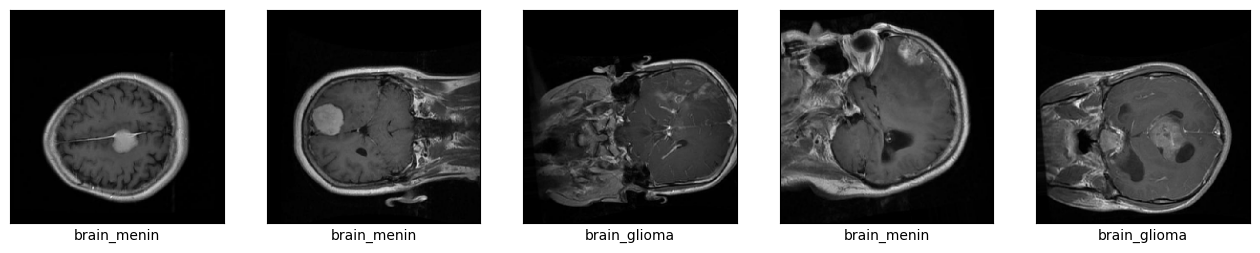

In [ ]:
import os

#Let's look at first 5 training data.
fig = plt.figure(figsize = (16,9))
for i in range(5):
    ax = fig.add_subplot(1,5,i+1,xticks=[],yticks=[])
    ax.imshow((X_ran[i].astype(np.uint8)))

    # Mendapatkan label kelas sebenarnya dari path file gambar
    file_path = X_random[i]  # Path file gambar
    folder_name = os.path.basename(os.path.dirname(file_path))  # Nama folder
    true_label = folder_name  # Label kelas sebenarnya

    # Menampilkan label kelas di bawah gambar
    ax.set_xlabel(true_label)

In [ ]:
# re-scale so that all values in X lie within 0 to 1
X_ran = X_ran.astype('float32')/255

# Let's confirm the number of classes ;)
no_of_classes = len(np.unique(y_random))
print(no_of_classes)

y_ran = np.array(to_categorical(y_random,no_of_classes))

# y[0]# Note that only one element has value 1(corresponding to its label) and others are 0.

3


In [ ]:
# Lets divide into training, validation and testing set

# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_trainn, X_test = X_ran, X_ran
y_trainn, y_test = y_ran, y_ran
X_train, X_val, y_train, y_val = train_test_split(X_trainn, y_trainn, test_size=0.2, random_state=42)
del X_trainn, y_trainn

In [ ]:
print('X : ',X_ran.shape[0])
print('')

print("Jumlah data X_train = ",X_train.shape[0])
print("Jumlah data X_test = ",X_test.shape[0])
print("Jumlah data X_val = ",X_val.shape[0])
print('')
print('y : ',y_ran.shape[0])
print('')
print("Jumlah data y_train = ",y_train.shape[0])
print("Jumlah data y_test = ",y_test.shape[0])
print("Jumlah data y_val = ",y_val.shape[0])

X :  800

Jumlah data X_train =  640
Jumlah data X_test =  800
Jumlah data X_val =  160

y :  800

Jumlah data y_train =  640
Jumlah data y_test =  800
Jumlah data y_val =  160


In [ ]:
base_model = applications.DenseNet201(weights='imagenet', include_top=False) #gantimodel disini
print('Loaded model!')

#Let's freeze the first 15 layers - if you see the VGG model layers below,
# we are freezing till the last Conv layer.
for layer in base_model.layers[:15]:
    layer.trainable = False

base_model.summary()

74850304/74836368 [==============================] - 0s 0us/step
Loaded model!
Model: "densenet201"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, None, None,   0          ['input_1[0][0]']                
                                3)                                                                
                                                                                                  
 conv1/conv (Conv2D)            (None, None, None,   9408        ['zero_padding2d[0][0]']         
         

In [ ]:
from tensorflow.keras import applications, optimizers
base_model.summary()

top_model = Sequential()
top_model.add(GlobalAveragePooling2D(input_shape=base_model.output_shape[1:]))
top_model.add(Dropout(0.2)) # Dropout dengan rate 0.5
top_model.add(Dense(no_of_classes, activation='softmax'))
top_model.summary()

model = Sequential()
model.add(base_model)
model.add(top_model)
model.summary()

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.Adam(learning_rate=0.0001),  # Use learning_rate instead of lr
              metrics=['accuracy'])

Model: "densenet201"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, None, None,   0          ['input_1[0][0]']                
                                3)                                                                
                                                                                                  
 conv1/conv (Conv2D)            (None, None, None,   9408        ['zero_padding2d[0][0]']         
                                64)                                                     

In [ ]:
# SALAH
# Time to train our model !
# from keras.callbacks import ModelCheckpoint
# epochs = 3
# batch_size=32
# model1_path = '/content/drive/MyDrive/Computer Vision/model1.hdf5' # Changed the extension to .keras

#train_datagen = ImageDataGenerator(
 #   shear_range=0.2,
 #   zoom_range=0.2,
 #   horizontal_flip=True)

test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(
    X_train,y_train,
    batch_size=batch_size)

validation_generator = test_datagen.flow(
    X_test,y_test,
    batch_size=batch_size)

checkpointer = ModelCheckpoint(model1_path,save_best_only = True,verbose = 1)

history = model.fit_generator(
    train_generator,
    steps_per_epoch=len(X_train) // batch_size,
    epochs= epochs ,
    validation_data=validation_generator,
    validation_steps=len(X_test) // batch_size,
    callbacks=[checkpointer])
np.save('/content/drive/MyDrive/Computer Vision/history_save.npy',history.history)

<ipython-input-14-4e6bf5840745>:25: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(


Epoch 1/3
20/20 [==============================] - ETA: 0s - loss: 0.6233 - accuracy: 0.4781 
Epoch 1: val_loss improved from inf to 0.42596, saving model to /content/drive/MyDrive/Computer Vision/model1.hdf5
20/20 [==============================] - 1415s 72s/step - loss: 0.6233 - accuracy: 0.4781 - val_loss: 0.4260 - val_accuracy: 0.7788
Epoch 2/3
20/20 [==============================] - ETA: 0s - loss: 0.4290 - accuracy: 0.6984 
Epoch 2: val_loss improved from 0.42596 to 0.31550, saving model to /content/drive/MyDrive/Computer Vision/model1.hdf5
20/20 [==============================] - 1419s 73s/step - loss: 0.4290 - accuracy: 0.6984 - val_loss: 0.3155 - val_accuracy: 0.7788
Epoch 3/3
20/20 [==============================] - ETA: 0s - loss: 0.3307 - accuracy: 0.7812 
Epoch 3: val_loss improved from 0.31550 to 0.24780, saving model to /content/drive/MyDrive/Computer Vision/model1.hdf5
20/20 [==============================] - 1389s 71s/step - loss: 0.3307 - accuracy: 0.7812 - val_loss:

In [ ]:
# Time to train our model !
from keras.callbacks import ModelCheckpoint
epochs = 5
batch_size=32
model1_path = '/content/drive/MyDrive/Computer Vision/TugasAkhir/model1.keras' # Changed the extension to .keras


train_datagen = ImageDataGenerator(
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(
    X_train,y_train,
    batch_size=batch_size)

validation_generator = test_datagen.flow(
    X_test,y_test,
    batch_size=batch_size)

checkpointer = ModelCheckpoint(model1_path,save_best_only = True,verbose = 1)

# Use model.fit instead of model.fit_generator
history = model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // batch_size,
    epochs= epochs ,
    validation_data=validation_generator,
    validation_steps=len(X_test) // batch_size,
    callbacks=[checkpointer])
np.save('/content/drive/MyDrive/Computer Vision/history_save.npy',history.history)

Epoch 1/5
20/20 [==============================] - ETA: 0s - loss: 0.0100 - accuracy: 0.9984
Epoch 1: val_loss improved from inf to 0.23630, saving model to /content/drive/MyDrive/Computer Vision/TugasAkhir/model1.keras
20/20 [==============================] - 172s 8s/step - loss: 0.0100 - accuracy: 0.9984 - val_loss: 0.2363 - val_accuracy: 0.8525
Epoch 2/5
20/20 [==============================] - ETA: 0s - loss: 0.0114 - accuracy: 0.9937
Epoch 2: val_loss improved from 0.23630 to 0.10565, saving model to /content/drive/MyDrive/Computer Vision/TugasAkhir/model1.keras
20/20 [==============================] - 161s 8s/step - loss: 0.0114 - accuracy: 0.9937 - val_loss: 0.1056 - val_accuracy: 0.9413
Epoch 3/5
20/20 [==============================] - ETA: 0s - loss: 0.0113 - accuracy: 0.9969
Epoch 3: val_loss improved from 0.10565 to 0.09182, saving model to /content/drive/MyDrive/Computer Vision/TugasAkhir/model1.keras
20/20 [==============================] - 160s 8s/step - loss: 0.0113 - a

In [ ]:
import tensorflow as tf
import numpy as np

model_path = '/content/drive/MyDrive/Computer Vision/TugasAkhir/model1.keras'  # Use .keras extension
history_path = '/content/drive/MyDrive/Computer Vision/history_save.npy'

# Load the model using tf.keras.models.load_model
model = tf.keras.models.load_model(model_path)

# Load the history using np.load and convert to dictionary
history = np.load(history_path, allow_pickle=True).item()

In [ ]:
# SALAH
# model_path = '/content/drive/MyDrive/Computer Vision/model1.hdf5';
# history_path = '/content/drive/MyDrive/Computer Vision/history_save.npy'

# model = load_model(model_path);
# history=np.load(history_path,allow_pickle='TRUE').item()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/pooling/base_global_pooling.py:12: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [ ]:
# model.load_weights(model1_path)
(eval_loss, eval_accuracy) = model.evaluate(
     X_test, y_test, batch_size=batch_size, verbose=1)

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("Accuracy: {:.2f}%".format(eval_accuracy * 100))
print("Loss: {}".format(eval_loss))
print("")
print("Jumlah data X_train = ",X_train.shape[0])
print("Jumlah data X_test = ",X_test.shape[0])

print('')

# Print classification report
report = classification_report(y_true_classes, y_pred_classes, target_names=labels)
print(report)

25/25 [==============================] - 30s 1s/step - loss: 0.0138 - accuracy: 0.9950
Accuracy: 99.50%
Loss: 0.013848390430212021

Jumlah data X_train =  640
Jumlah data X_test =  800

              precision    recall  f1-score   support

brain_glioma       1.00      1.00      1.00       281
 brain_menin       0.99      0.99      0.99       265
 brain_tumor       0.99      1.00      0.99       254

    accuracy                           0.99       800
   macro avg       0.99      0.99      0.99       800
weighted avg       1.00      0.99      1.00       800



Text(0.5, 155.58159722222217, 'Predicted')

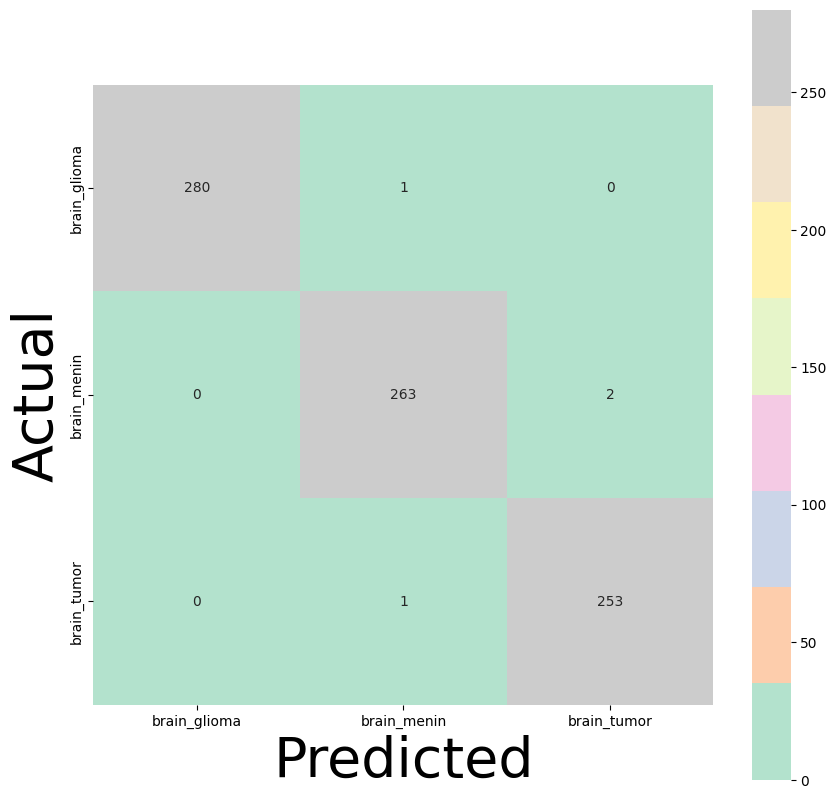

In [ ]:
# Confusion Matrix
Y_pred = model.predict(X_test)

Y_pred = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(Y_true, Y_pred)
plt.figure(figsize=(10, 10))
ax = sns.heatmap(cm, cmap=plt.cm.Pastel2, annot=True, square=True, xticklabels=labels, yticklabels=labels,fmt='d')
ax.set_ylabel('Actual', fontsize=40)
ax.set_xlabel('Predicted', fontsize=40)

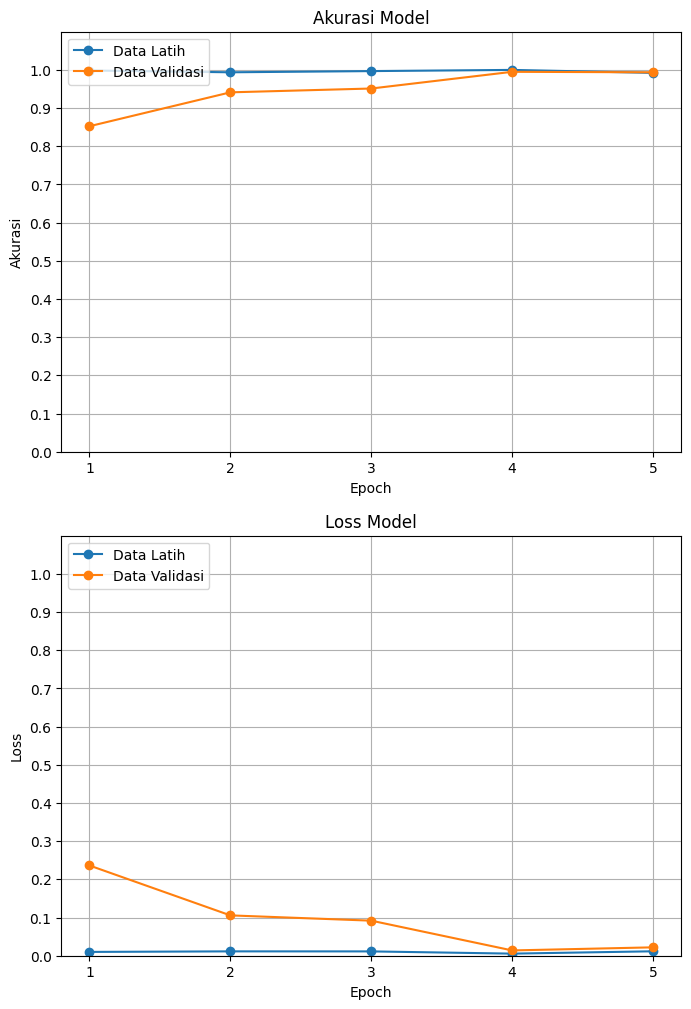

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot(history):
    """
    Fungsi untuk memplot akurasi dan loss dari history pelatihan model.

    Args:
        history: Dictionary yang berisi history pelatihan model.
    """
    plt.figure(figsize=(8, 12))

    # Membaca jumlah epoch yang tersedia dalam history data
    num_epochs = len(history['accuracy'])

    # Membuat range epoch 1 hingga 10
    epochs = list(range(1, num_epochs + 1))

    # Plot akurasi
    plt.subplot(211)
    plt.plot(epochs, history['accuracy'], marker='o', label='Data Latih')
    plt.plot(epochs, history['val_accuracy'], marker='o', label='Data Validasi')
    plt.title('Akurasi Model')
    plt.ylabel('Akurasi')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')
    plt.xticks(ticks=range(1, 6))  # Menampilkan semua nilai 1 hingga 10 di x-axis
    plt.yticks(ticks=np.arange(0, 1.1, 0.1))  # Menambahkan detail pada sumbu Y
    plt.ylim([0, 1.1])  # Menyesuaikan range akurasi antara 0 dan 1
    plt.grid(True)

    # Plot loss
    plt.subplot(212)
    plt.plot(epochs, history['loss'], marker='o', label='Data Latih')
    plt.plot(epochs, history['val_loss'], marker='o', label='Data Validasi')
    plt.title('Loss Model')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')
    plt.xticks(ticks=range(1, 6))  # Menampilkan semua nilai 1 hingga 10 di x-axis
    plt.yticks(ticks=np.arange(0, 1.1, 0.1))  # Menambahkan detail pada sumbu Y
    plt.ylim([0, 1.1])  # Menyesuaikan range loss antara 0 dan 1
    plt.grid(True)

    # Tambahkan nilai pada tiap titik di loss
    #for i, val in enumerate(history['loss']):
        #plt.text(epochs[i], val, f"{val:.2f}", fontsize=8, ha='center', va='bottom')
    #for i, val in enumerate(history['val_loss']):
        #plt.text(epochs[i], val, f"{val:.2f}", fontsize=8, ha='center', va='bottom')

    #plt.tight_layout()
    plt.show()

# Memuat history data dari file
history_path = '/content/drive/MyDrive/Computer Vision/history_save.npy'  # Ganti dengan path file history Anda
history = np.load(history_path, allow_pickle=True).item()

# Memastikan nilai x adalah 1-10
max_epoch = 10
history['accuracy'] = history['accuracy'][:max_epoch]
history['val_accuracy'] = history['val_accuracy'][:max_epoch]
history['loss'] = history['loss'][:max_epoch]
history['val_loss'] = history['val_loss'][:max_epoch]

# Memanggil fungsi plot
plot(history)


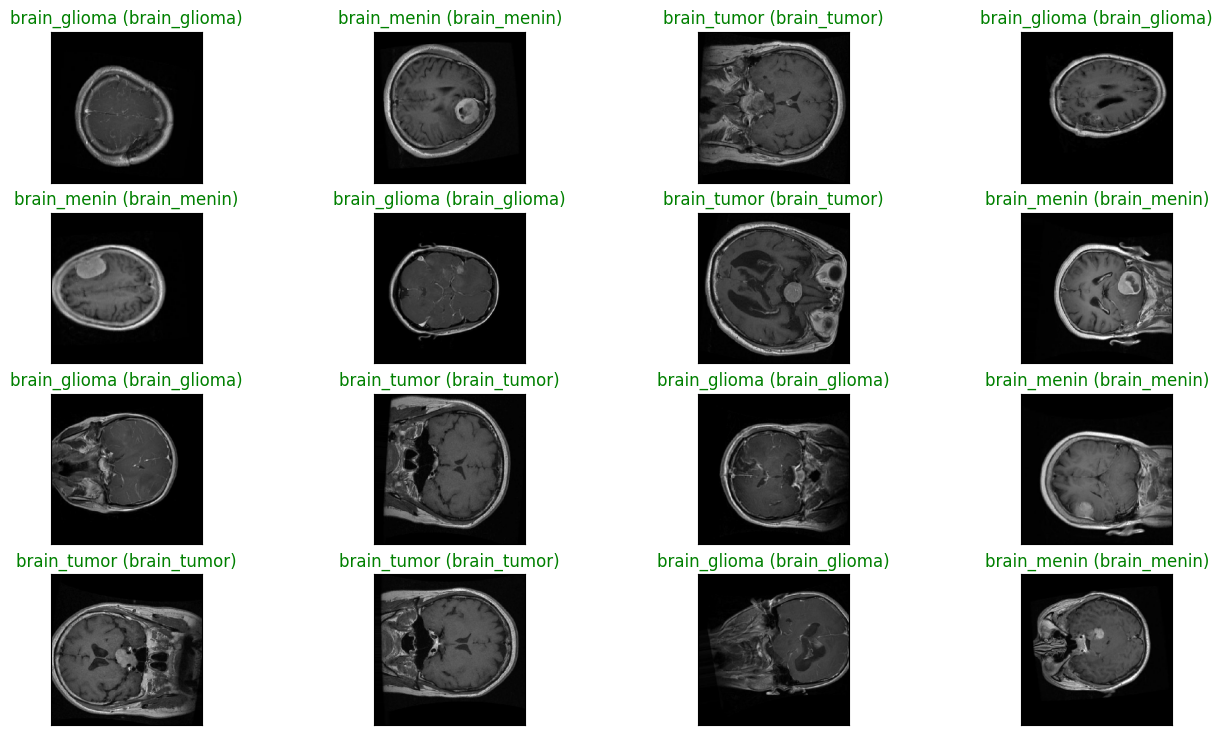

In [ ]:
# Let's visualize some random test prediction.
def visualize_pred(y_pred):
# plot a random sample of test images, their predicted labels, and ground truth
    fig = plt.figure(figsize=(16, 9))
    for i, idx in enumerate(np.random.choice(X_test.shape[0], size=16, replace=False)):# mengambil gmbar random sejumlh 16 dari X_test
        ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[]) #4,4 itu adalah 4 gambar x 4 gambar kebawah
        ax.imshow(np.squeeze(X_test[idx]))
        pred_idx = np.argmax(y_pred[idx])
        true_idx = np.argmax(y_test[idx])
        ax.set_title("{} ({})".format(labels[pred_idx], labels[true_idx]),
                     color=("green" if pred_idx == true_idx else "red"))

visualize_pred(model.predict(X_test))

In [ ]:
|